In [1]:
import spectral as spi
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from spectral import *
import cv2
from patches_functions import *
from dataset_functions import *
from load_dataset import *


/opt/conda/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# 1649.76: 254 | 1750.08:272 | 1772.34: 276 | 1949.96:308
datapath = Path(r'Path to dataset/training (ref)/')
paths = ["HSI_im/hsi",
        "HSI_im2/Plastics_5_5.0_6.0_refl.FENIX",
        "HSI_im3/RAMSES_5_5.0_6.0_refl.FENIX",
        "PE/PE_HD_std1_VNIR_SWIR",
        "PE/PE_LD_std1_VNIR_SWIR",
        "PE/PE_UHMW_std1_VNIR_SWIR",
        "PET/PET_std1_VNIR_SWIR",
        "PP/PP_std1_VNIR_SWIR"]
index1 = 254
index2 = 308
HSI, GT = read_data(datapath,paths, index1, index2)

0
0.0 1.0023417 (335, 725, 360)
1
0.0 1.0 (335, 700, 360)
[0 1 2 3 4 5 6] (335, 700)
2
0.0 1.0 (395, 904, 360)
[0 1 2 3 4 5 6] (395, 904)
3
0.039917601281757836 0.30864423590447854 (14, 13, 360)
[6.] (14, 13)
4
0.0081025406271458 0.18223849851224536 (13, 13, 360)
[6.] (13, 13)
5
0.061036087586785685 0.33319600213626305 (13, 12, 360)
[6.] (13, 12)
6
0.005539024948500801 0.08499275196459907 (9, 9, 360)
[4.] (9, 9)
7
0.01634241245136187 0.1416189822232395 (11, 11, 360)
[1.] (11, 11)


In [3]:
HSI[0].shape, HSI[-1].shape, len(GT), len(HSI)

((335, 725, 54), (11, 11, 54), 8, 8)

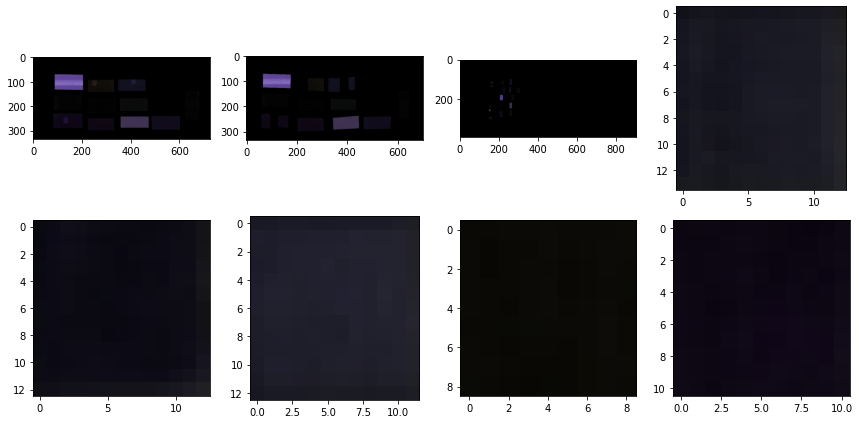

In [4]:
plot_images(HSI)

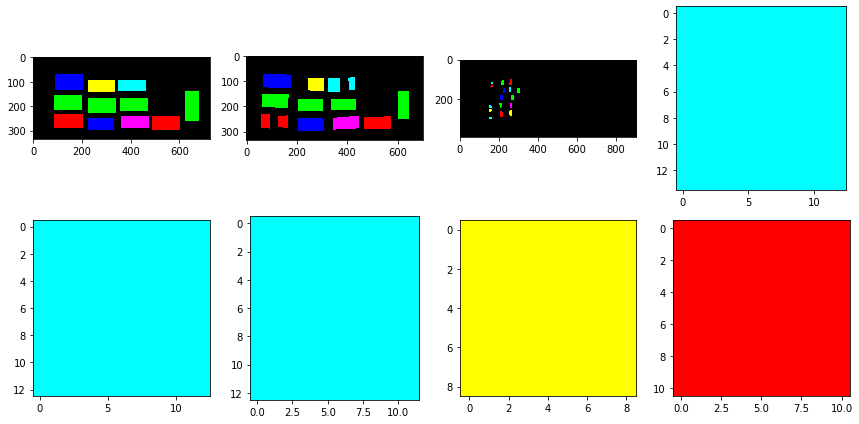

In [5]:
plot_images(GT)

(46, 92, 54)
0.0 0.5465018692301823


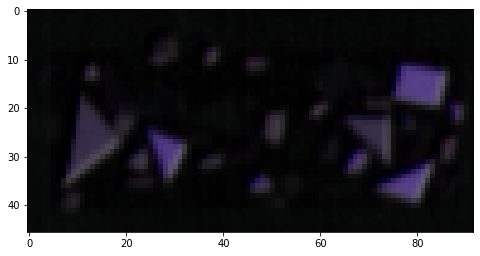

In [6]:
# Read the HS files
datapath = Path(r'/home/arbash44/coding/hsi/whispers24/test (mixed)/')

header_file = str(datapath / 'mixed_FENIX_crop.hdr')
data_file = str(datapath / 'mixed_FENIX_crop.dat')

numpy_ndarr = envi.open(header_file, data_file)
test = spi.io.bipfile.BipFile.open_memmap(numpy_ndarr) / 65535.
test = test[:,:,index1:index2]
print(test.shape)
print(np.min(test), np.max(test))
# Select the Bands
bands = numpy_ndarr.bands.centers
bands = bands[index1:index2]

fig = plt.figure(figsize=(8,6))
plt.imshow(test[:,:,(-1, 10, 1)])

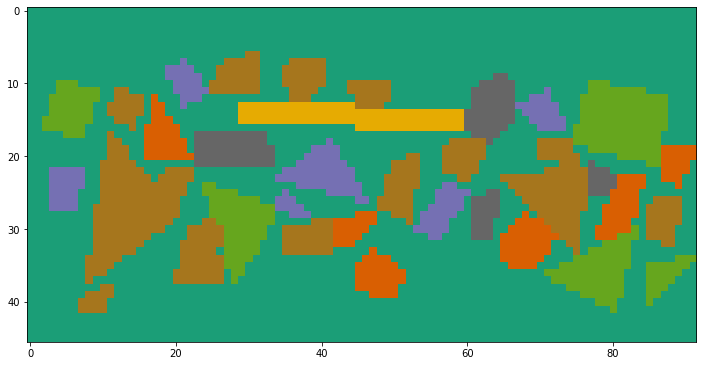

In [7]:
output_file_path = '/home/arbash44/coding/hsi/whispers24/test (mixed)/Test_GT.png'
test_GT = cv2.imread(output_file_path)
test_GT = cv2.cvtColor(test_GT, cv2.COLOR_BGR2GRAY)
plt.figure(figsize = (12,8))
plt.imshow(test_GT, cmap = 'Dark2', interpolation='None')

In [8]:
# Augmenting the training data
from augmentations import *
# Initialize new lists to hold augmented data
augmented_HSI = []
augmented_GT = []

# Define the list of augmentation functions
augmentation_functions = [
    spectral_shift,
    spectral_smoothing,
    spectral_noise,
    spectral_scaling,
    spectral_channel_dropping
]

# Iterate over each HSI and GT pair
for idx, (hsi, gt) in enumerate(zip(HSI, GT)):
    # Append the original HSI and GT
    augmented_HSI.append(hsi)
    augmented_GT.append(gt)
    
    # Apply each augmentation
    for aug_func in augmentation_functions:
        # Apply the augmentation
        augmented_hsi = aug_func(hsi)
        # Ensure that the augmented_hsi has the same shape as the original
        assert augmented_hsi.shape == hsi.shape, f"Augmented HSI shape mismatch: {augmented_hsi.shape} vs {hsi.shape}"
        
        # Append the augmented HSI and the same GT mask
        augmented_HSI.append(augmented_hsi)
        augmented_GT.append(gt)

len(augmented_HSI), len(augmented_GT)

(48, 48)

In [9]:
for i, hsi in enumerate(HSI):
    print(np.min(hsi), np.max(hsi))

0.0 0.7749751
0.0 0.7674372472724499
0.0 1.0
0.039917601281757836 0.1734950789654383
0.0081025406271458 0.14378576333257037
0.061036087586785685 0.19685664148928053
0.011367971313038834 0.06037994964522774
0.01634241245136187 0.10263218127718013


In [10]:
def normalize_hsi_bandwise_with_mask(hsi, mask):
    normalized_hsi = np.copy(hsi)
    for b in range(hsi.shape[2]):  # iterate over bands
        relevant_pixels = hsi[:, :, b][mask > 0]  # select only relevant pixels
        min_val = np.min(relevant_pixels)
        max_val = np.max(relevant_pixels)
        normalized_hsi[:, :, b] = (hsi[:, :, b] - min_val) / (max_val - min_val)
        # Ensure the background remains zero after normalization
        normalized_hsi[:, :, b][mask == 0] = 0
    return normalized_hsi

# Apply band-wise normalization with mask to all HSIs
normalized_HSI_bandwise = [normalize_hsi_bandwise_with_mask(hsi, gt) for hsi, gt in zip(HSI, GT)]
test = normalize_hsi_bandwise_with_mask(test, test_GT)

In [11]:
for i, hsi in enumerate(normalized_HSI_bandwise):
    print(np.min(hsi), np.max(hsi))
print(np.min(test), np.max(test))

0.0 1.0
0.0 1.0
0.0 1.0
0.0 1.0
0.0 1.0
0.0 1.0
0.0 1.0
0.0 1.0
0.0 1.0


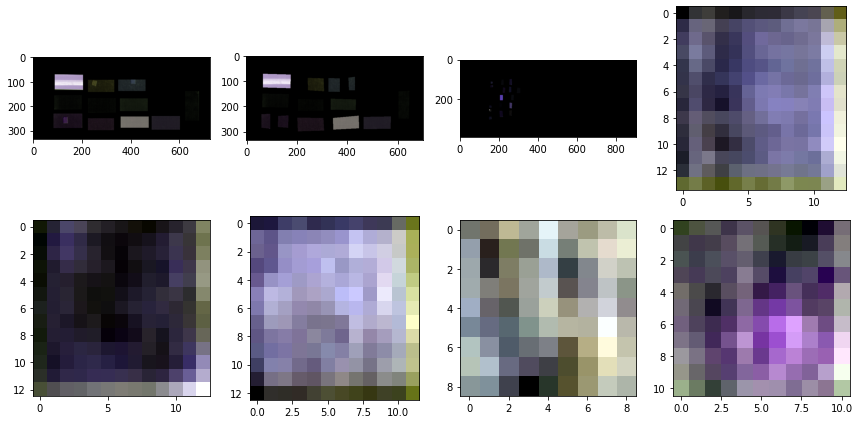

In [12]:
plot_images(normalized_HSI_bandwise)

In [13]:
def extract_features_and_labels(hsi_input, mask_input, ignore_classes=[0]):
    """
    Extract feature vectors and labels from HSI image and mask, ignoring specified classes.
    
    Parameters:
        hsi (numpy.ndarray): The HSI image.
        mask (numpy.ndarray): The corresponding ground truth mask.
        ignore_classes (list, optional): List of classes to be ignored. Defaults to [0].
    
    Returns:
        X (numpy.ndarray): Array of feature vectors.
        y (numpy.ndarray): Array of labels.
    """
    X = []
    y = []
    
    if isinstance(hsi_input,list) and isinstance(mask_input,list):
        hsi_list = hsi_input
        mask_list = mask_input
    else:
        hsi_list = [hsi_input]
        mask_list = [mask_input]
        
    for hsi,mask in zip(hsi_list, mask_list):
        h, w, c = hsi.shape
        
        for i in range(h):
            for j in range(w):
                label = mask[i, j]
                if label not in ignore_classes:
                    X.append(hsi[i, j, :])
                    y.append(label)
    
    X = np.array(X)
    y = np.array(y)
    
    return X, y

In [14]:
train_X, train_y = extract_features_and_labels(normalized_HSI_bandwise, GT, ignore_classes=[0, 7, 8])

print(train_X.shape, train_y.shape, np.min(train_y), np.max(train_y), np.min(train_X), np.max(train_X))


(126690, 54) (126690,) 1.0 6.0 0.0 1.0


In [15]:
test_X, test_y = extract_features_and_labels(test, test_GT, ignore_classes=[0])
test_X.shape, test_y.shape, np.min(test_y), np.max(test_y), np.min(test_X), np.max(test_X)

((1466, 54), (1466,), 1, 6, 0.0, 1.0)

In [16]:
import numpy as np

def split_test_set(test_X, test_y, train_X, train_y, split_ratio=0.20, augmentations=None, num_augments=100):
    """
    From the test set (test_X, test_y), take a proportion (split_ratio),
    apply augmentations (num_augments times), and add augmented samples to
    train set (train_X, train_y). The test set remains intact.
    
    Parameters:
        test_X (numpy.ndarray): Test set features.
        test_y (numpy.ndarray): Test set labels.
        train_X (numpy.ndarray): Training set features.
        train_y (numpy.ndarray): Training set labels.
        split_ratio (float): Proportion of test set to use for augmentation.
        augmentations (list of functions): List of augmentation functions to apply.
        num_augments (int): Number of times to augment each sample.
    
    Returns:
        train_X (numpy.ndarray): Updated training set features with augmented data.
        train_y (numpy.ndarray): Updated training set labels with augmented data.
    """
    num_test_samples = len(test_X)
    num_val_samples = int(num_test_samples * split_ratio)
    
    # Randomly select a subset of the test set
    indices = np.random.permutation(num_test_samples)
    val_indices = indices[:num_val_samples]
    
    val_X = test_X[val_indices]
    val_y = test_y[val_indices]
    
    if augmentations:
        augmented_X = []
        augmented_y = []
        for _ in range(num_augments):
            for x, y in zip(val_X, val_y):
                x_aug = x.copy()
                for aug in augmentations:
                    x_aug = aug(x_aug)
                augmented_X.append(x_aug)
                augmented_y.append(y)
        augmented_X = np.array(augmented_X)
        augmented_y = np.array(augmented_y)
        # Add augmented samples to train_X and train_y
        train_X = np.concatenate([train_X, augmented_X], axis=0)
        train_y = np.concatenate([train_y, augmented_y], axis=0)
    else:
        # If no augmentations, just add val_X and val_y to train_X and train_y
        train_X = np.concatenate([train_X, val_X], axis=0)
        train_y = np.concatenate([train_y, val_y], axis=0)
    
    return train_X, train_y


# Update the training set with augmented data
train_X, train_y = split_test_set(
    test_X, test_y, 
    train_X, train_y, 
    split_ratio=0.20, 
    augmentations=augmentation_functions, 
    num_augments=100
)

print(test_X.shape, test_y.shape, np.min(test_y), np.max(test_y), np.min(test_X), np.max(test_X))
print(train_X.shape, train_y.shape, np.min(train_y), np.max(train_y), np.min(train_X), np.max(train_X))


(1466, 54) (1466,) 1 6 0.0 1.0
(155990, 54) (155990,) 1.0 6.0 -0.1941842206823608 1.0796875971413682


In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
train_X = scaler.fit_transform(train_X)
test_X = scaler.transform(test_X)

# Define the parameter grid for k
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11]
}

# Create the KNN classifier
knn = KNeighborsClassifier()

# # Perform grid search with 5-fold cross-validation
grid_search = GridSearchCV(knn, param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(train_X, train_y)

# # Get the best hyperparameters
best_params = grid_search.best_params_
print(f"Best parameters found: {best_params}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters found: {'n_neighbors': 11}


In [18]:
import json

# Save the best parameters to a JSON file
with open('KNN_best_params2.json', 'w') as file:
    json.dump(best_params, file)

In [19]:
import json

# Load the best parameters from the JSON file
with open('KNN_best_params2.json', 'r') as file:
    best_params = json.load(file)

In [20]:
# Train the KNN model with the best parameters
best_knn = KNeighborsClassifier(n_neighbors=best_params['n_neighbors'])
best_knn.fit(train_X, train_y)

KNeighborsClassifier(n_neighbors=11)

In [21]:
# Make predictions on the test set
test_predictions = best_knn.predict(test_X)

In [22]:
test_predictions.shape , type(test_predictions), test_y.shape, type(test_y),

((1466,), numpy.ndarray, (1466,), numpy.ndarray)

In [23]:
np.unique(test_y), np.unique(test_predictions)

(array([1, 2, 3, 4, 5, 6], dtype=uint8), array([1., 2., 3., 4., 5., 6.]))

In [24]:
test_predictions2 = test_predictions - 1
test_y2 = test_y - 1

In [25]:
np.unique(test_y2), np.unique(test_predictions2)


(array([0, 1, 2, 3, 4, 5], dtype=uint8), array([0., 1., 2., 3., 4., 5.]))

In [26]:
# Caculate the segmentation metrics
confusion_matrix_sum, true_positive_sum, true_negative_sum, false_positive_sum, false_negative_sum, precision, recall, f1_score, pixel_accuracy_per_class, pixel_accuracy, iou, dice_coefficient, kappa = evaluate_segmentation(test_y2, test_predictions2, 6)

# Print the evaluation metrics
print("Confusion Matrix:")
print(confusion_matrix_sum)
print("Pixel Accuracy:")
print(pixel_accuracy)
print("Precision:")
print(precision)
print("Recall:")
print(recall)
print("F1 Score:")
print(f1_score)
print("Intersection over Union (IoU):")
print(iou)
print("Dice Coefficient:")
print(dice_coefficient)
print("Kappa Coefficient:")
print(kappa)

Confusion Matrix:
[[ 65  41  36  52   0   2]
 [  0 162   0   9   0   0]
 [ 24  49 193  27   0  32]
 [  0  90   0   3   0   0]
 [ 45  93 154  89 154   5]
 [ 10  37   2  76   0  16]]
Pixel Accuracy:
0.4045020463847203
Precision:
[0.45138889 0.34322034 0.5012987  0.01171875 1.         0.29090909]
Recall:
[0.33163265 0.94736842 0.59384615 0.03225806 0.28518519 0.11347518]
F1 Score:
[0.38235294 0.50388802 0.54366197 0.01719198 0.44380403 0.16326531]
Intersection over Union (IoU):
[0.23636364 0.33679834 0.37330754 0.00867052 0.28518519 0.08888889]
Dice Coefficient:
[0.38235294 0.50388802 0.54366197 0.01719198 0.44380403 0.16326531]
Kappa Coefficient:
[0.37045582 0.37501349 0.34584046 0.38881866 0.30023905 0.38039634]


In [28]:
def reconstruct_image(h, w, data, mask, predictions, ignore_classes=[0]):
    """
    Reconstruct the prediction image from the predictions array.
    
    Parameters:
        h (int): Height of the original image.
        w (int): Width of the original image.
        data (numpy.ndarray): Array of feature vectors.
        mask (numpy.ndarray): The corresponding ground truth mask.
        predictions (numpy.ndarray): The predictions array.
        ignore_classes (list, optional): List of classes to be ignored. Defaults to [0].
    
    Returns:
        reconstructed_image (numpy.ndarray): The reconstructed image.
    """
    reconstructed_image = np.zeros((h, w), dtype=np.int64)
    pred_idx = 0
    
    for i in range(h):
        for j in range(w):
            label = mask[i, j]
            if label not in ignore_classes:
                reconstructed_image[i, j] = predictions[pred_idx]
                pred_idx += 1
    
    return reconstructed_image

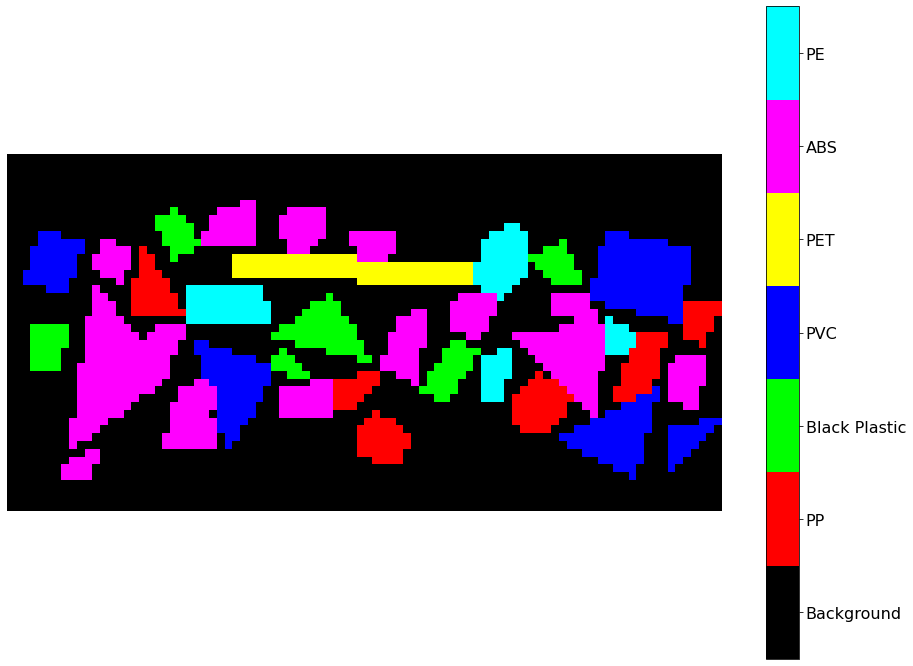

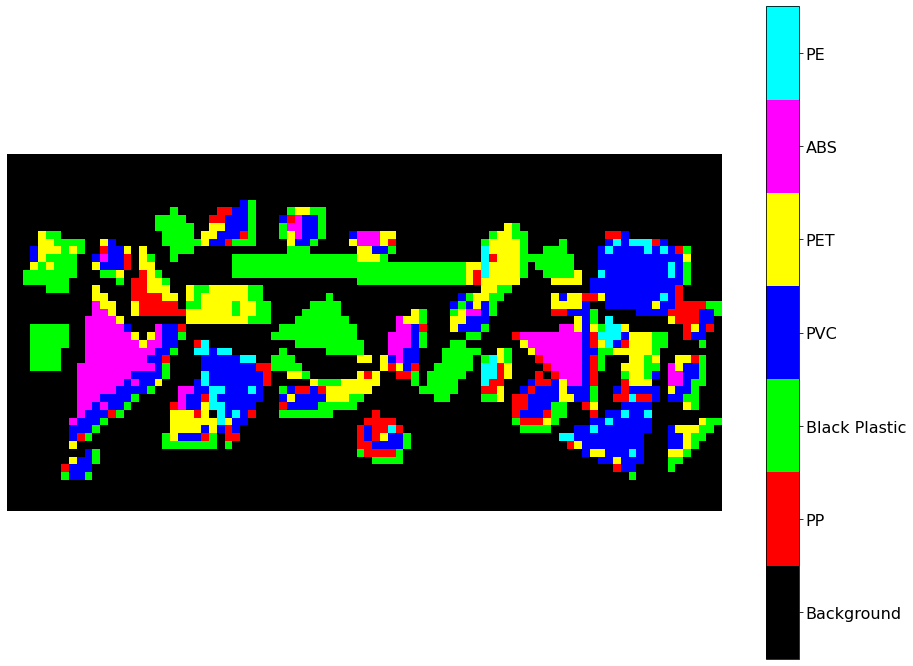

[CV] END ......................................n_neighbors=5; total time=  38.5s
[CV] END ......................................n_neighbors=3; total time=  39.7s
[CV] END ......................................n_neighbors=5; total time=  39.7s
[CV] END ......................................n_neighbors=7; total time=  39.9s
[CV] END ......................................n_neighbors=9; total time=  40.0s
[CV] END ......................................n_neighbors=3; total time=  40.4s
[CV] END .....................................n_neighbors=11; total time=  40.7s
[CV] END ......................................n_neighbors=7; total time=  41.8s
[CV] END ......................................n_neighbors=3; total time=  42.4s
[CV] END .....................................n_neighbors=11; total time=  42.4s
[CV] END .....................................n_neighbors=11; total time=  42.5s
[CV] END ......................................n_neighbors=7; total time=  42.9s
[CV] END ...................

In [29]:
from matplotlib.colors import ListedColormap, BoundaryNorm

# Reconstruct the prediction image
h, w, _ = test.shape
prediction_map = reconstruct_image(h, w, test, test_GT, test_predictions, ignore_classes=[0])
test_GT

# Define the class names
class_names = ['Background', 'PP', 'Black Plastic', 'PVC', 'PET', 'ABS', 'PE']

# Define the colors for each class
colors = ['#000000', '#FF0000', '#00FF00', '#0000FF', '#FFFF00', '#FF00FF', '#00FFFF']  # Example colors

# Create a colormap
cmap = ListedColormap(colors)

# Create a normalization object
norm = BoundaryNorm(np.arange(0, 8), cmap.N)

# Plot the ground truth map
fig, ax = plt.subplots(figsize = [16,12])
cax = ax.imshow(test_GT, cmap=cmap, norm=norm)
# Hide the axes
ax.axis('off')
# Create the color bar
cbar = fig.colorbar(cax, ticks=np.arange(0.5, 7.5, 1))
cbar.ax.set_yticklabels(class_names, fontsize=16)
# Define the class names
class_names = ['Background', 'PP', 'Black Plastic', 'PVC', 'PET', 'ABS', 'PE']

# Define the colors for each class
colors = ['#000000', '#FF0000', '#00FF00', '#0000FF', '#FFFF00', '#FF00FF', '#00FFFF']  # Example colors

# Create a colormap
cmap = ListedColormap(colors)

# Create a normalization object
norm = BoundaryNorm(np.arange(0, 8), cmap.N)

# Plot the ground truth map
fig, ax = plt.subplots(figsize = [16,12])
cax = ax.imshow(prediction_map, cmap=cmap, norm=norm)
# Hide the axes
ax.axis('off')
# Create the color bar
cbar = fig.colorbar(cax, ticks=np.arange(0.5, 7.5, 1))
cbar.ax.set_yticklabels(class_names, fontsize=16)
# Show the plot
plt.show()